# Summary

**Overview:**

- Historically, science treated the Estrogen Receptor (ER) and Progesterone Receptor (PR) as two totally separate players in breast cancer. The current study looked at the "cross-talk" between Estrogen Receptor (ER) and Progesterone Receptor (PR) in ER positive breast cancer. 

**Study Design:**

- This study compared cells with the aggressive, therapy-resistant Estrogen Receptor mutation (Y537S) against cells carrying the normal, unmutated Estrogen Receptor (WT).

**The Treatment Switch:**

- Superimposed on top of those genetics, researchers looked at what happens when you actively destroy the Progesterone Receptor (shPR) versus leaving it completely intact (shGFP control).


**Key Insight:**

- The ER mutants need the Progesterone Receptor to run. When you take PR away (shPR), the mutant's aggressive expression signature collapses and looks almost just like the wild-type.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Load data
counts = pd.read_csv("./gene-counts/gene_level_counts.csv", index_col="gene_id")

# Verify the shape 
print(f"Matrix loaded successfully! Shape: {counts.shape}")

Matrix loaded successfully! Shape: (82323, 11)


In [3]:
counts.head(10)

,SRR36108971,SRR36108972,SRR36108973,SRR36108974,SRR36108976,SRR36108977,SRR36108978,SRR36108979,SRR36108980,SRR36108981,SRR36108982
gene_id,,,,,,,,,,,
ENSG00000000003,1762,2645,2274,714,1101,1981,2101,2243,2207,1585,2270
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,1
ENSG00000000419,8136,10668,9888,12897,18399,10080,10331,10722,8668,5876,8774
ENSG00000000457,1625,2242,2072,698,888,1773,1930,2129,3479,2452,3256
ENSG00000000460,1049,1626,1459,462,657,1587,1606,1803,1518,939,1608
ENSG00000000938,14,16,10,3,2,2,13,11,5,8,2
ENSG00000000971,19,41,32,14,17,11,39,34,35,34,45
ENSG00000001036,4001,5522,4756,2336,2902,5365,5618,6169,5232,3963,5215
ENSG00000001084,3190,4986,4409,4831,7073,5690,6308,6148,5301,3805,5170


In [4]:
# Filter out zero or ultra-low expression genes to clean up noise
# (Keeps genes with at least 10 total reads across all 11 samples)
counts_filtered = counts[counts.sum(axis=1) >= 10]

# Log-transform the data to stabilize variance: log2(counts + 1)
log_counts = np.log2(counts_filtered + 1)

# Transpose so that Samples are rows and Genes are columns
# (Scikit-learn expects observations/samples as rows)

df_pca = log_counts.T

print(f"Original shape: {counts.shape}")
print(f"Filtered shape for EDA: {counts_filtered.shape}")

Original shape: (82323, 11)
Filtered shape for EDA: (37205, 11)


# Scale & Fit PCA

In [5]:
from sklearn.pipeline import Pipeline

pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

In [6]:
# Fit the pipeline and transform the data all at once!

pca = pca_pipeline.fit_transform(df_pca)

# Extract the variance explained dynamically from the pipeline steps
var_explained = pca_pipeline.named_steps['pca'].explained_variance_ratio_ * 100

print(var_explained)

[30.94928169 20.73294644]


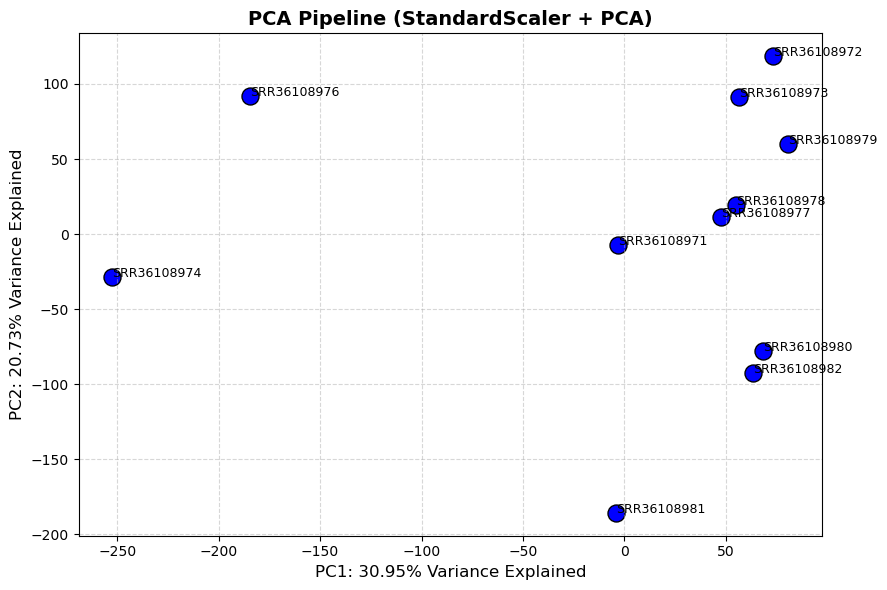

In [7]:
# Convert coordinates into a plotting DataFrame
pca_df = pd.DataFrame(
    data=pca, 
    columns=['PC1', 'PC2'], 
    index=df_pca.index
).reset_index().rename(columns={'index': 'Sample'})

# Generate the plot
plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', s=150, color='blue', edgecolor='black')

# Label the samples (SRR...)
for i in range(len(pca_df)):
    plt.text(pca_df['PC1'][i] + 0.1, pca_df['PC2'][i] + 0.1, pca_df['Sample'][i], fontsize=9)

plt.title('PCA Pipeline (StandardScaler + PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1: {var_explained[0]:.2f}% Variance Explained', fontsize=12)
plt.ylabel(f'PC2: {var_explained[1]:.2f}% Variance Explained', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# The Scree Plot "Elbow" Method

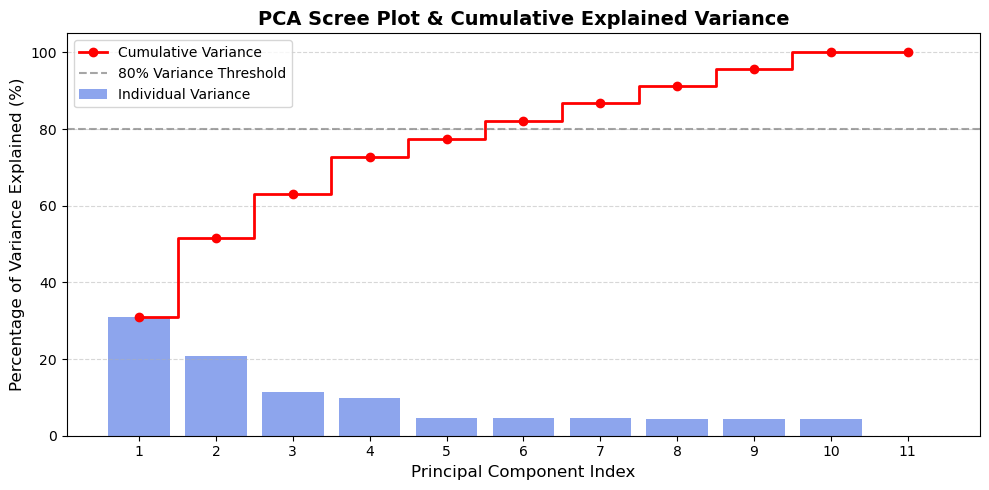

In [8]:
# Initialize the pipeline to compute all possible components (11 samples = 11 max PCs)
full_pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=11))
])

# Fit the pipeline
full_pca_pipeline.fit(df_pca)

# Extract individual and calculate cumulative variances
ind_variance = full_pca_pipeline.named_steps['pca'].explained_variance_ratio_ * 100
cum_variance = np.cumsum(ind_variance)

# Generate the Scree Plot
plt.figure(figsize=(10, 5))

# Plot individual variance (Bar chart)
plt.bar(range(1, 12), ind_variance, alpha=0.6, color='royalblue', label='Individual Variance')

# Plot cumulative variance (Line chart)
plt.step(range(1, 12), cum_variance, where='mid', color='red', marker='o', linewidth=2, label='Cumulative Variance')

# Visual aid line at 80% threshold
plt.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% Variance Threshold')

plt.title('PCA Scree Plot & Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component Index', fontsize=12)
plt.ylabel('Percentage of Variance Explained (%)', fontsize=12)
plt.xticks(range(1, 12))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

To capture at least 80% of variance, I would need 6 to 7 n components. 

# Create the Clean Metadata Table

In [9]:
# Define metadata records with SRR36108981 correctly grouped
metadata_records = {
    'SRR36108971': {'genotype': 'Y537S', 'treatment': 'shPR',  'group': 'Y537S_shPR'},
    'SRR36108972': {'genotype': 'Y537S', 'treatment': 'shPR',  'group': 'Y537S_shPR'},
    'SRR36108973': {'genotype': 'Y537S', 'treatment': 'shPR',  'group': 'Y537S_shPR'},
    'SRR36108974': {'genotype': 'Y537S', 'treatment': 'shGFP', 'group': 'Y537S_shGFP'},
    'SRR36108976': {'genotype': 'Y537S', 'treatment': 'shGFP', 'group': 'Y537S_shGFP'},
    'SRR36108977': {'genotype': 'WT',    'treatment': 'shPR',  'group': 'WT_shPR'},
    'SRR36108978': {'genotype': 'WT',    'treatment': 'shPR',  'group': 'WT_shPR'},
    'SRR36108979': {'genotype': 'WT',    'treatment': 'shPR',  'group': 'WT_shPR'},
    'SRR36108980': {'genotype': 'WT',    'treatment': 'shGFP', 'group': 'WT_shGFP'},
    'SRR36108981': {'genotype': 'WT',    'treatment': 'shGFP', 'group': 'WT_shGFP'},
    'SRR36108982': {'genotype': 'WT',    'treatment': 'shGFP', 'group': 'WT_shGFP'}
}

# Convert to DataFrame
metadata_df = pd.DataFrame.from_dict(metadata_records, orient='index')
metadata_df.index.name = 'sample_id'

# Overwrite the design file
metadata_df.to_csv("./sample_metadata.csv")
print("✅ Updated sample_metadata.csv successfully!")
print(metadata_df['group'].value_counts())

✅ Updated sample_metadata.csv successfully!
group
Y537S_shPR     3
WT_shPR        3
WT_shGFP       3
Y537S_shGFP    2
Name: count, dtype: int64


## Regenerate the Color-Coded PCA Plot

In [10]:
# Ensure the count matrix columns match the metadata samples exactly (dropping any unused samples)
active_samples = list(metadata_records.keys())
counts_active = counts[active_samples]

# Re-run the log-transform and pipeline logic
counts_filtered = counts_active[counts_active.sum(axis=1) >= 10]
log_counts = np.log2(counts_filtered + 1)
df_pca = log_counts.T

# Fit your pipeline (from previous turn)
pca_features = pca_pipeline.fit_transform(df_pca)
var_explained = pca_pipeline.named_steps['pca'].explained_variance_ratio_ * 100

# Format PCA coordinates
pca_plot_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'], index=df_pca.index)
pca_plot_df = pca_plot_df.merge(metadata_df, left_index=True, right_index=True).reset_index()


In [11]:
pca_plot_df.head()

,index,PC1,PC2,genotype,treatment,group
0,SRR36108971,-3.152411,-7.109627,Y537S,shPR,Y537S_shPR
1,SRR36108972,73.009220,118.530234,Y537S,shPR,Y537S_shPR
2,SRR36108973,56.317416,91.023186,Y537S,shPR,Y537S_shPR
3,SRR36108974,-252.395870,-28.388815,Y537S,shGFP,Y537S_shGFP
4,SRR36108976,-184.338192,92.071831,Y537S,shGFP,Y537S_shGFP


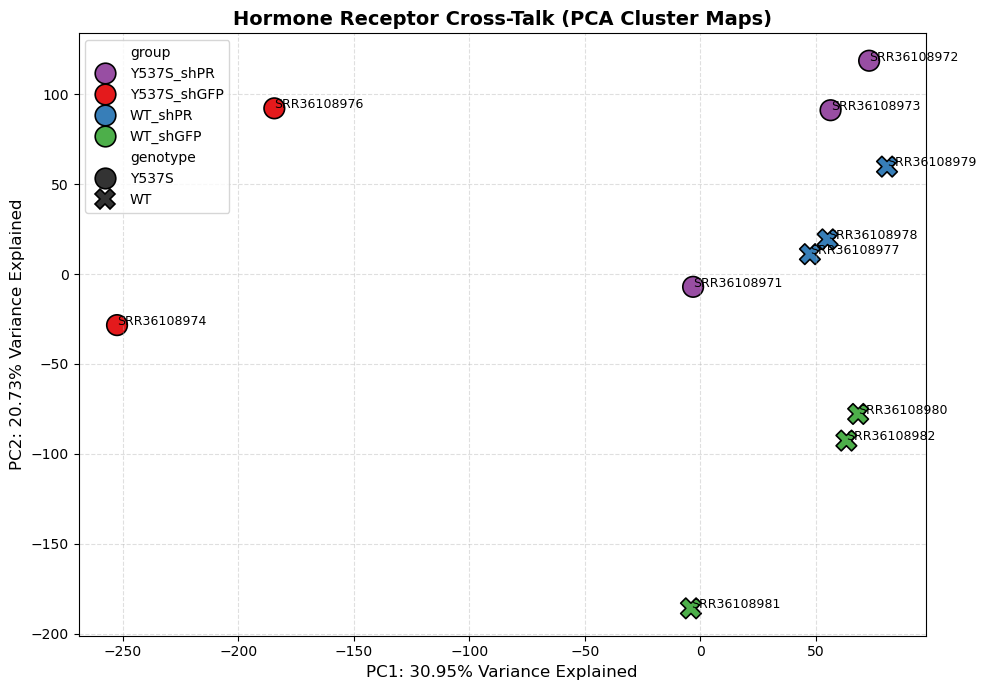

In [12]:
# Plot the biological groups
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_plot_df, 
    x='PC1', y='PC2', 
    hue='group', 
    style='genotype',
    s=220, 
    edgecolor='black', 
    palette={'WT_shGFP': '#4daf4a', 'WT_shPR': '#377eb8', 'Y537S_shGFP': '#e41a1c', 'Y537S_shPR': '#984ea3'}
)
# Label the samples (SRR...)
for i in range(len(pca_plot_df)):
    plt.text(pca_plot_df['PC1'][i] + 0.1, pca_plot_df['PC2'][i] + 0.1, pca_plot_df['index'][i], fontsize=9)

plt.title('Hormone Receptor Cross-Talk (PCA Cluster Maps)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1: {var_explained[0]:.2f}% Variance Explained', fontsize=12)
plt.ylabel(f'PC2: {var_explained[1]:.2f}% Variance Explained', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Key Insights:

1. The Left Outliers: Mutant Controls (Y537S + shGFP)

- Samples (SRR36108974 & SRR36108976): Mutant Y537S, Control shGFP.

**The insight:** 

- These two samples are separated along the PC1 axis. This indicates that when the Y537S mutation is active and PR is left alone (shGFP), the cells switch on a completely unique transcriptomic profile. This profile is distinct from everything else on the plate, driving 30.39% of the overall variance.

2. The Right Wall: Wild-Types and Knockdowns

- Samples 71 (SRR36108971 to 73): Mutant Y537S, but with shPR treatment.
- Samples 78 (SRR36108978 to 79): Wild-Type WT for estrogen receptor with shPR treatment.
- Samples (SRR36108980 to 82): Wild-Type ER with shGFP treatment 

**The insight:** 

- Knocking down the Progesterone Receptor (shPR) in the Y537S mutant cells pulls Samples 71 to 73 completely out of the left outlier zone and shifts them to the right, grouping them alongside the Wild-Type samples.

- This indicates that knocking down PR rescues or reverses the mutant phenotype, returning the gene expression patterns closer to a normal state.


# Sample-to-Sample Distance Heatmap

In [13]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage

# Compute pairwise Euclidean distance matrix between sample rows
distance_matrix = squareform(pdist(df_pca, metric='euclidean'))

# Convert to a readable DataFrame
distance_df = pd.DataFrame(distance_matrix, index=df_pca.index, columns=df_pca.index)

# Compute the condensed 1D distance vector
condensed_distances = pdist(df_pca, metric='euclidean')

# Compute the linkage matrix directly from the distances
row_linkage = linkage(condensed_distances, method='average')
col_linkage = linkage(condensed_distances, method='average')

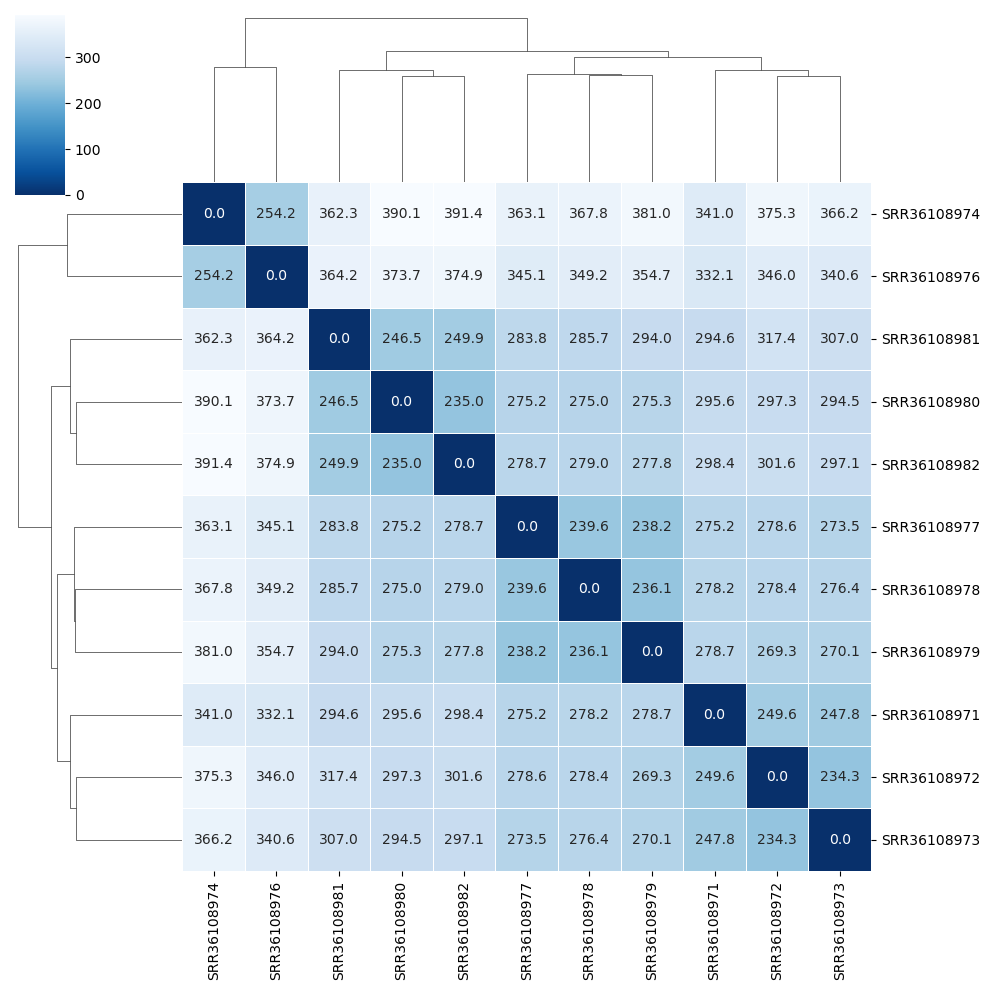

In [14]:
# Pass the square distance dataframe along with your custom linkages
sns.clustermap(
    distance_df,
    row_linkage=row_linkage,
    col_linkage=col_linkage,
    cmap='Blues_r',
    annot=True,
    fmt=".1f",
    linewidths=.5
)
plt.show()

Sample-to-sample distance heatmap uses full log-transformed data matrix to calculate the exact mathematical Euclidean distance between the full transcription profiles of every single sample pair.

## Key Insights:

- Three insights can be deduced from this plot that perfectly match and validate the PCA plot.

### 1. The Mutant Group Isolation (SRR36108974 & SRR36108976)

- These two samples are the Y537S mutant cells treated with control shGFP.

- **Internal Similarity:** They share a dark blue square with a distance of 247.9 between each other. They are highly similar.

- **Global Isolation:** Their distance numbers to every other sample in the experiment are big (ranging from 332 to 391).

- The Splicing Tree (Dendrogram): The clustering tree creates a separate primary branch just for these two samples, splitting them away from the rest of the plate. This confirms that the active Y537S mutation creates a highly unique, detached transcriptomic state.


### 2. The Clean Replicate Blocks

- **The WT_shGFP baseline state:** SRR36108981, SRR36108980, and SRR36108982 cluster closely together. Their pairwise distances are low.

- **The WT_shPR knockdown state:** SRR36108978, SRR36108977, and SRR36108979 lock together with distances from 234 to 349.


### 3. Cross-Talk Confirmation: The Y537S_shPR Rescue

- The heatmap clearly confirms the cross-talk between ER and PR:

- Samples SRR36108971, SRR36108972, and SRR36108973 are the Y537S mutant cells treated with the PR knockdown (shPR).

- They form a tight cluster with each other.

- They directly share a branch with the WT_shPR group (77, 78, 79).

- They do not cluster anywhere near their genetic mutant siblings (74 and 76). Instead, their global Euclidean distance shifts closer to the wild-type profile.


## Conclusion 

- The therapeutic mechanism is clear: Knocking down the Progesterone Receptor removes the distinct transcriptomic fingerprint of the active Y537S mutation, pulling those cancer cells into a wild-type expression state.

# Get Gene Symbols

In [15]:
import mygene

# Load the list of unique gene IDs (using filtered count matrix index)
# Assuming counts_filtered is dataframe from the EDA steps
gene_ids = counts_filtered.index.tolist()

# Initialize the MyGene query engine
mg = mygene.MyGeneInfo()

# Query the database 
# feed the IDs, specify working with humans, and request 'symbol' and 'name'
print(f"Querying names for {len(gene_ids)} genes...")
queries = mg.querymany(
    gene_ids, 
    scopes='ensembl.gene,refseq', # Covers Ensembl or RefSeq formats automatically
    fields='symbol,name', 
    species='human',
    as_dataframe=True
)

Querying names for 37205 genes...


32 input query terms found dup hits:	[('ENSG00000117262', 2), ('ENSG00000188092', 2), ('ENSG00000188660', 2), ('ENSG00000226519', 2), ('E


In [16]:
# Clean up the resulting dataframe
# MyGene returns the original query as the index
anno_df = queries[['symbol', 'name']].copy()
anno_df.index.name = 'gene_id'

# Drop any duplicate rows if they popped up during query matching
anno_df = anno_df.reset_index().drop_duplicates(subset=['gene_id']).set_index('gene_id')

# Save the annotation mapping to a CSV for future reference
anno_df.to_csv("./gene_annotation_mapping.csv", index=True)

print("✅ Annotation mapping dataframe created successfully!")
print(anno_df.head())

✅ Annotation mapping dataframe created successfully!
                 symbol                                               name
gene_id                                                                   
ENSG00000000003  TSPAN6                                      tetraspanin 6
ENSG00000000419    DPM1  dolichyl-phosphate mannosyltransferase subunit...
ENSG00000000457   SCYL3                           SCY1 like pseudokinase 3
ENSG00000000460   FIRRM  FIGNL1 interacting regulator of recombination ...
ENSG00000000938     FGR     FGR proto-oncogene, Src family tyrosine kinase
